# Analyse des Variables Clés : Choix du Modèle Électrique

**Objectif principal :** Ce notebook a pour but de créer un modèle prédictif (XGBoost) dédié spécifiquement à la consommation électrique. L'objectif n'est pas seulement de faire des prédictions, mais surtout d'**identifier les caractéristiques physiques du bâtiment (isolation, année, surface, etc.) qui influencent le plus la facture d'électricité**, en évitant les fuites de données (data leakage).

### Déroulement de l'analyse :
1. **Préparation de la Cible (Target) :** Isolation de la consommation purement électrique (en combinant l'énergie n°1 et n°2 si elles sont électriques).
2. **Modèle de Débroussaillage (Naïf) :** Un premier modèle entraîné sur la quasi-totalité des colonnes (en retirant les mots évidents comme "Cout" ou "Etiquette") pour avoir une première idée des variables influentes.
3. **Modèle Ciblé ("Liste Blanche") :** Un second modèle entraîné **uniquement** sur une liste stricte de caractéristiques physiques (features) sélectionnées à la main. Cela garantit un top des variables 100% fiable et actionnable sans "triche" algorithmique.

### Importations
Cette cellule initialise l'environnement de travail. On importe toutes les bibliothèques d'analyse (Pandas, Numpy) et de modélisation (Scikit-Learn, XGBoost). On configure également l'affichage visuel avec Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

### Chargement du Dataset
On charge ici les données départementales brutes (ici, le département 78 : Yvelines). L'avertissement de Pandas sur les "mixed types" est normal pour les gros fichiers CSV et n'impacte pas l'analyse à ce stade.

In [2]:
nom_region = "Yvelines"
df=pd.read_csv('Dpe_dep_78.csv')

C:\Users\lilym\AppData\Local\Temp\ipykernel_20616\173015095.py:2: DtypeWarning: Columns (156) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Dpe_dep_78.csv')


## Préparation du Dataset 

### Création de la Cible (Target)

Préparation du Dataset. L'objectif est de prédire l'électricité. On crée donc une nouvelle colonne conso_totale_elec_finale. Le code cherche si l'énergie principale (n°1) ou secondaire (n°2) est de l'électricité, et additionne les consommations correspondantes pour chaque logement.

In [9]:
# On initialise la nouvelle colonne à 0 pour tout le monde
df['conso_totale_elec_finale'] = 0

# On vérifie l'énergie n°1
df['conso_totale_elec_finale'] = np.where(
    df['type_energie_n1'] == 'Électricité', 
    df['conso_5_usages_ef_energie_n1'], 
    df['conso_totale_elec_finale']
)

# On ajoute l'énergie n°2 (si jamais l'électricité est en 2ème position)
df['conso_totale_elec_finale'] = np.where(
    df['type_energie_n2'] == 'Électricité', 
    df['conso_totale_elec_finale'] + df['conso_5_usages_ef_energie_n2'], 
    df['conso_totale_elec_finale']
)



## Choix du modèle

### Premier Modèle 

Étape 1. C'est l'approche d'exclusion. On prend toutes les données du dataset, mais on exclut les mots qui pourraient biaiser le modèle (fuites de données : on ne veut pas prédire l'électricité en utilisant la colonne "Coût de l'électricité"). Le modèle XGBoost gère nativement les catégories grâce à enable_categorical=True.

Nombre de NaN dans y : 7
Taille du dataset après nettoyage : 92617 lignes.
Entraînement en cours...


<Figure size 1000x800 with 0 Axes>

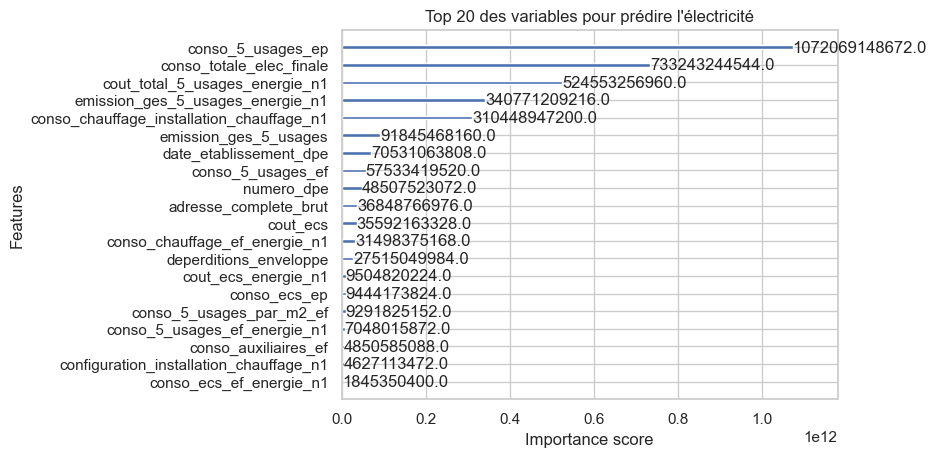

Nombre de variables conservées pour le modèle final : 11


In [11]:
# 1. Définir tes features (X) et ta target (y)
# (Assure-toi d'avoir calculé df['conso_totale_elec_finale'] avant)
y = df['conso_totale_elec_finale']

# On supprime les fuites de données et les identifiants
mots_interdits = ['Conso', 'Cout', 'Emission', 'Etiquette', 'N°', 'Date']
colonnes_a_garder = [col for col in df.columns if not any(mot in col for mot in mots_interdits)]
X = df[colonnes_a_garder]

# 2. Convertir toutes les colonnes de texte (object) en type "category"
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')


# ... (votre code précédent pour définir X et y) ...

# 1. Optionnel mais recommandé : Vérifier combien de lignes posent problème
print(f"Nombre de NaN dans y : {y.isna().sum()}")

# 2. Supprimer de X et y les lignes où y est NaN ou Infini
# (Il faut supprimer la ligne entière pour que X et y gardent la même taille)
masque_valide = ~y.isna() & ~np.isinf(y)

X = X[masque_valide]
y = y[masque_valide]

print(f"Taille du dataset après nettoyage : {len(y)} lignes.")

# ... (Suite de votre code : instanciation du modèle puis model.fit(X, y)) ...

# 3. Instancier un modèle XGBoost rapide (pas besoin de tuner les paramètres pour l'instant)
# L'argument enable_categorical=True est le secret ici
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=5,
    enable_categorical=True, 
    random_state=42,
    n_jobs=-1 # Utilise tous les cœurs de ton processeur
)

# 4. Entraîner le modèle (ça peut prendre quelques minutes vu la taille du dataset)
print("Entraînement en cours...")
model.fit(X, y)

# 5. Afficher le Top 20 des variables les plus importantes
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=20, importance_type='gain', title="Top 20 des variables pour prédire l'électricité")
plt.show()

# 6. (Optionnel) Récupérer la liste exacte pour la suite
importances = pd.Series(model.feature_importances_, index=X.columns)
colonnes_conservees = importances[importances > 0.01].index.tolist() # Garde celles qui ont un impact > 1%
print(f"Nombre de variables conservées pour le modèle final : {len(colonnes_conservees)}")

### Modèle Final (Variables Actionnables)

Étape 2 (Le vrai modèle). Pour éviter tout biais caché, on utilise ici une Liste Blanche. On sélectionne à la main uniquement les caractéristiques techniques du logement. 

*Note : Les données sont désormais séparées en Train/Test pour évaluer la vraie performance du modèle (R² et MAE) avant d'afficher l'importance des variables.*

In [ ]:
# 1. Vos listes de variables "Actionnables" (La Liste Blanche)
features_cat = [
    'type_batiment', 
    'zone_climatique', 
    'classe_altitude',
    'chauffage_simplifie',        
    'logement_traversant_clean',  
    'isolation_toiture_clean',
    'qualite_isolation_enveloppe',
    'periode_construction',
    'qualite_isolation_murs',
    'qualite_isolation_menuiseries',
    'qualite_isolation_plancher_bas',
    'type_emetteur_installation_chauffage_n1',
    'type_installation_ecs',
    'type_generateur_n1_ecs_n1',
    'presence_brasseur_air',
    'protection_solaire_exterieure',
    'numero_DPE'
]

features_num = [
    'surface_habitable_logement',
    'annee_construction', 
    'hauteur_sous_plafond',
    'ubat_w_par_m2_k',
    'besoin_chauffage',
    'apport_solaire_saison_chauffe'
]

# On combine les deux listes pour créer notre X complet
colonnes_a_garder = features_cat + features_num

# 2. Définir X et y (en s'assurant que les colonnes existent bien dans df)
# On filtre pour ne garder que les colonnes qui sont bien présentes dans le dataset
colonnes_presentes = [col for col in colonnes_a_garder if col in df.columns]
X = df[colonnes_presentes].copy()
y = df['conso_totale_elec_finale'].copy()

# 3. Nettoyage vital de la cible y (supprimer les NaN)
masque_valide = ~y.isna() & ~np.isinf(y)
X = X[masque_valide]
y = y[masque_valide]

print(f"Entraînement sur {len(y)} logements avec {len(colonnes_presentes)} variables d'ingénierie.")

# 4. Gérer le texte pour XGBoost
for col in features_cat:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 4. Gérer le texte (catégories) pour XGBoost
for col in features_cat:
    if col in X.columns:
        # L'astuce : on force le passage en texte (.astype(str)) 
        # AVANT de le convertir en catégorie
        X[col] = X[col].astype(str).astype('category')

# 5. Instancier et entraîner le modèle
model = xgb.XGBRegressor(
    n_estimators=150, 
    max_depth=6,
    enable_categorical=True, 
    random_state=42,
    n_jobs=-1
)

print("Entraînement en cours (sans triche cette fois !)...")
model.fit(X, y)


# 6. Afficher le Top des variables
plt.figure(figsize=(12, 8))
xgb.plot_importance(
    model, 
    importance_type='gain', 
    max_num_features=20, 
    title="Top des variables physiques pour prédire l'électricité",
    xlabel="Gain d'information",
    ylabel="Caractéristiques du bâtiment"
)
plt.tight_layout()
plt.show()

Entraînement sur 92617 logements avec 22 variables d'ingénierie.
Entraînement en cours (sans triche cette fois !)...


NameError: name 'y_test' is not defined